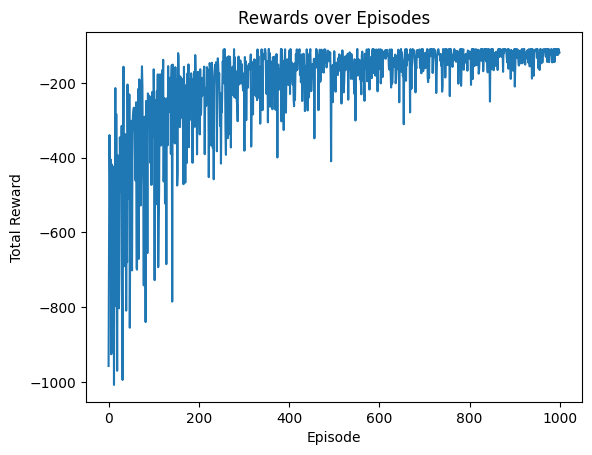

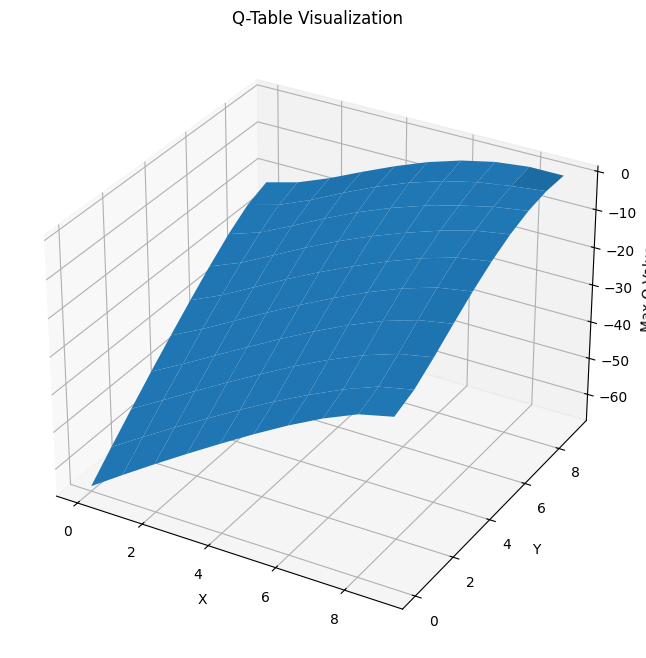

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# تعریف توابع عضویت فازی
def triangular_mf(x, a, b, c):
    return np.maximum(np.minimum((x - a) / (b - a), (c - x) / (c - b)), 0)

# تعریف کلاس ربات
class Robot:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def move(self, dx, dy):
        self.x += dx
        self.y += dy

# تعریف محیط
class Environment:
    def __init__(self, size):
        self.size = size
        self.goal = (size-1, size-1)

    def get_reward(self, robot):
        distance = np.sqrt((robot.x - self.goal[0])**2 + (robot.y - self.goal[1])**2)
        return -distance

# تعریف سیستم یادگیری تقویتی فازی
class FuzzyReinforcementLearning:
    def __init__(self, env_size):
        self.q_table = np.zeros((env_size, env_size, 4))  # 4 اکشن: بالا، پایین، چپ، راست
        self.alpha = 0.1
        self.gamma = 0.9
        self.epsilon = 0.1

    def get_action(self, robot):
        if np.random.random() < self.epsilon:
            return np.random.randint(4)
        else:
            return np.argmax(self.q_table[robot.x, robot.y])

    def update_q_table(self, robot, action, reward, new_x, new_y):
        old_q = self.q_table[robot.x, robot.y, action]
        max_future_q = np.max(self.q_table[new_x, new_y])
        new_q = (1 - self.alpha) * old_q + self.alpha * (reward + self.gamma * max_future_q)
        self.q_table[robot.x, robot.y, action] = new_q

# تابع اصلی برای اجرای شبیه‌سازی
def run_simulation(episodes, steps_per_episode):
    env = Environment(10)
    frl = FuzzyReinforcementLearning(env.size)
    rewards_history = []

    for episode in range(episodes):
        robot = Robot(0, 0)
        episode_reward = 0

        for step in range(steps_per_episode):
            action = frl.get_action(robot)
            old_x, old_y = robot.x, robot.y

            if action == 0:
                robot.move(0, 1)  # بالا
            elif action == 1:
                robot.move(0, -1)  # پایین
            elif action == 2:
                robot.move(-1, 0)  # چپ
            elif action == 3:
                robot.move(1, 0)  # راست

            robot.x = np.clip(robot.x, 0, env.size - 1)
            robot.y = np.clip(robot.y, 0, env.size - 1)

            reward = env.get_reward(robot)
            frl.update_q_table(Robot(old_x, old_y), action, reward, robot.x, robot.y)

            episode_reward += reward

            if (robot.x, robot.y) == env.goal:
                break

        rewards_history.append(episode_reward)

    return frl, rewards_history

# اجرای شبیه‌سازی
frl, rewards = run_simulation(1000, 100)

# نمایش نتایج
plt.plot(rewards)
plt.title('Rewards over Episodes')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.show()

# نمایش Q-table
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
x = y = np.arange(0, 10, 1)
X, Y = np.meshgrid(x, y)
Z = np.max(frl.q_table, axis=2)
ax.plot_surface(X, Y, Z)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Max Q-Value')
plt.title('Q-Table Visualization')
plt.show()
